<a href="https://colab.research.google.com/github/gurpreetsahotasingh288-gif/Python_program/blob/main/NETFLIX_TITLE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.shape

(8807, 12)

In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df['director']=df['director'].fillna('Not Available')
df['cast']=df['cast'].fillna('Not Avaible')
df['country']=df['country'].fillna('Not Available')
df['rating']=df['rating'].fillna(df['rating'].mode()[0])
df['date_added']=df['date_added'].fillna('Not Available')

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,3


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['date_added']=pd.to_datetime(df['date_added'],errors='coerce')

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Avaible,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Available,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Not Available,Not Avaible,Not Available,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Not Available,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df['type'].value_counts()

,count
type,
Movie,6128
TV Show,2676


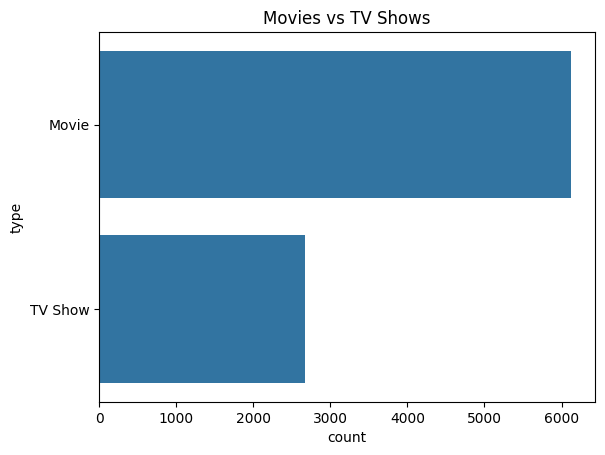

In [ ]:
sns.countplot(df['type'])
plt.title("Movies vs TV Shows")
plt.show()

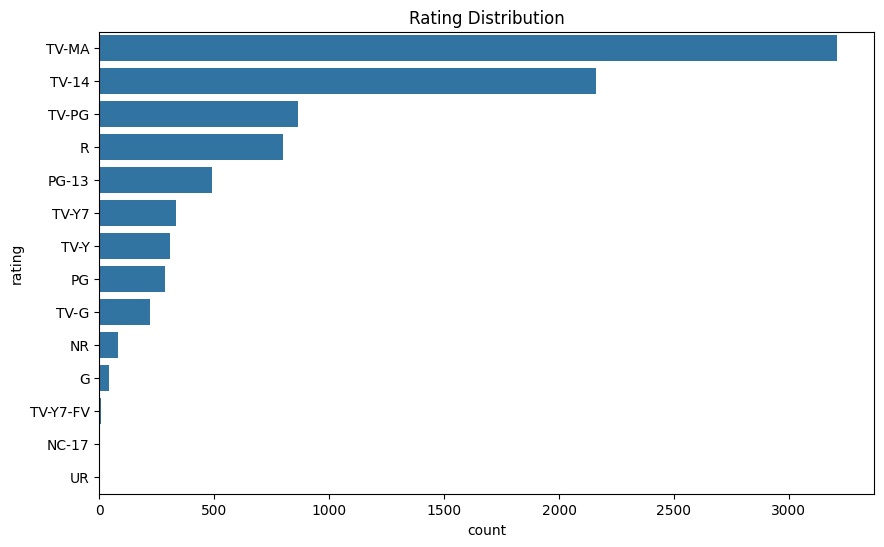

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(df['rating'],order=df['rating'].value_counts().index)
plt.title("Rating Distribution")
plt.show()

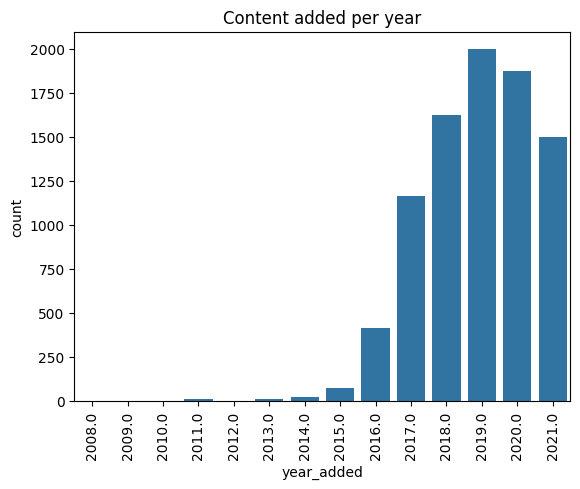

In [ ]:
df['year_added']=df['date_added'].dt.year
sns.countplot(x='year_added',data=df)
plt.xticks(rotation=90)
plt.title("Content added per year")
plt.show()

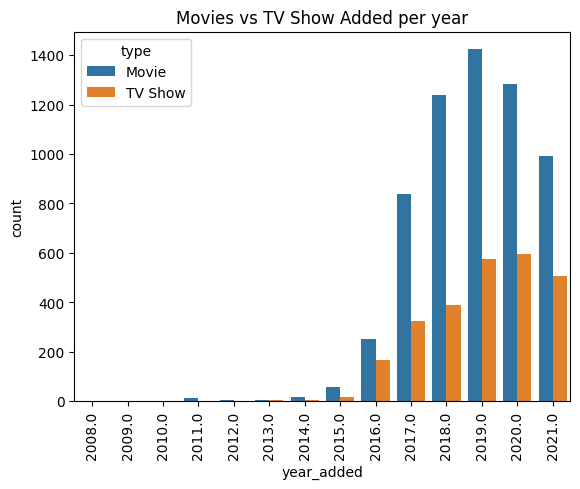

In [ ]:
sns.countplot(x='year_added',hue='type',data=df)
plt.xticks(rotation=90)
plt.title("Movies vs TV Show Added per year")
plt.show()

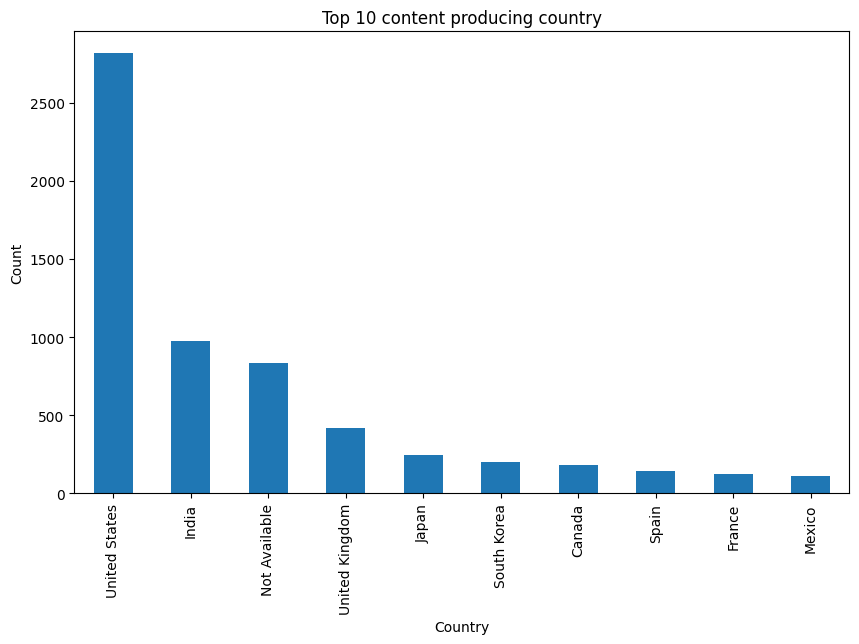

In [ ]:
top_countries=df['country'].value_counts().head(10)
plt.figure(figsize=(10,6))
top_countries.plot(kind='bar')
plt.title("Top 10 content producing country")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

In [ ]:
df_movies=df[df['type']=='Movie'].copy()

df_movies['duration_minutes']=df_movies['duration'].str.replace('min','',regex=True)
df_movies['duration_minutes']=pd.to_numeric(df_movies['duration_minutes'],errors='coerce')


In [ ]:
df_movies.dropna(subset=['duration_minutes'],inplace=True)

In [ ]:
df_movies

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,duration_minutes
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Avaible,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,90
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Not Available,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021.0,91
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0,125
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0,104
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021.0,127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan",2016-03-09,2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...,2016.0,96
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019.0,158
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019.0,88
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020.0,88


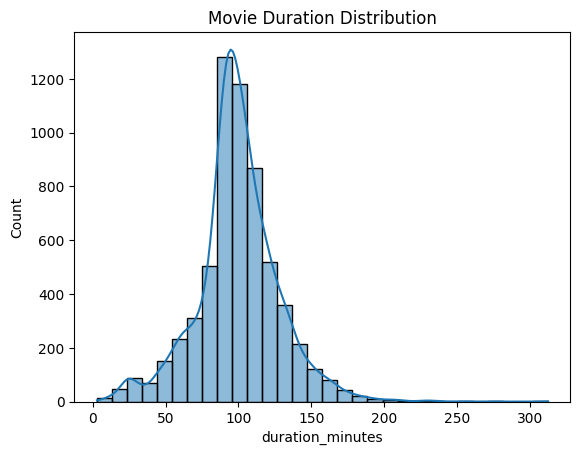

In [ ]:
sns.histplot(df_movies['duration_minutes'],bins=30,kde=True)
plt.title('Movie Duration Distribution')
plt.show()

In [ ]:
df['listed_in'].value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,220
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


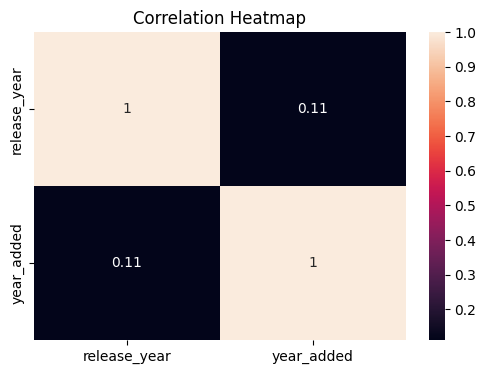

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
Q1=df_movies['duration_minutes'].quantile(0.25)
Q2=df_movies['duration_minutes'].quantile(0.50)
Q3=df_movies['duration_minutes'].quantile(0.75)
Q1,Q2,Q3

(np.float64(87.0), np.float64(98.0), np.float64(114.0))

In [ ]:
IQR=Q3-Q1
IQR

np.float64(27.0)

In [ ]:
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
lower_bound,upper_bound

(np.float64(46.5), np.float64(154.5))

In [ ]:
outliers=df_movies[(df_movies['duration_minutes']<lower_bound)|(df_movies['duration_minutes']>upper_bound)]
outliers[['title','duration_minutes']].head(10)

,title,duration_minutes
22,Avvai Shanmughi,161
24,Jeans,166
45,My Heroes Were Cowboys,23
71,A StoryBots Space Adventure,13
73,King of Boys,182
166,Once Upon a Time in America,229
177,The Guns of Navarone,156
202,Kyaa Kool Hai Hum,165
341,Magnolia,189
392,Django Unchained,165


In [ ]:
outliers[['title','duration_minutes']].tail(10)

,title,duration_minutes
8587,Thunderbolt,42
8629,Trimurti,173
8639,Tukaram,162
8657,Under an Arctic Sky,40
8707,"We, the Marines",38
8763,WWII: Report from the Aleutians,45
8764,Wyatt Earp,191
8770,Yaadein,171
8788,You Carry Me,157
8802,Zodiac,158


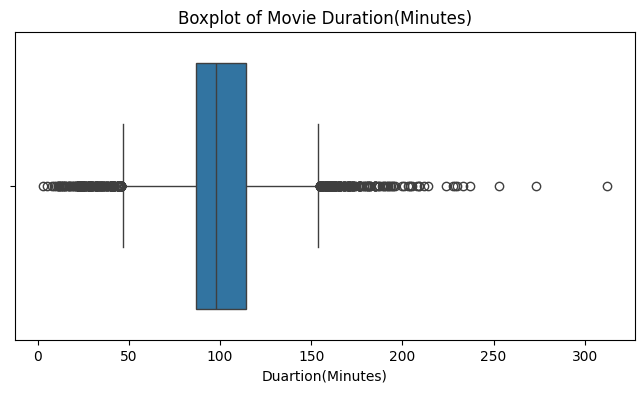

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_movies['duration_minutes'])
plt.title("Boxplot of Movie Duration(Minutes)")
plt.xlabel('Duartion(Minutes)')
plt.show()

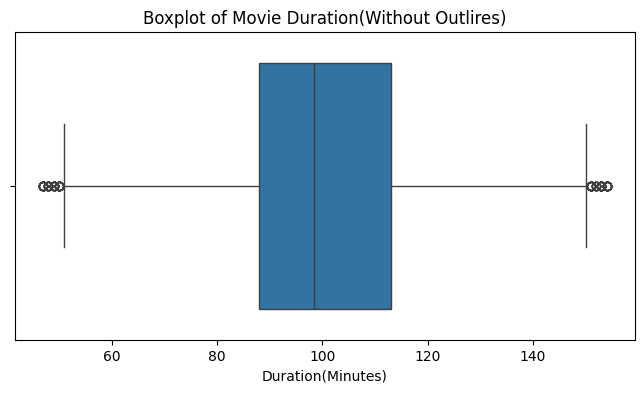

In [ ]:
filtered_movies=df_movies[(df_movies['duration_minutes']>=lower_bound)&
                          (df_movies['duration_minutes']<=upper_bound)]
plt.figure(figsize=(8,4))
sns.boxplot(x=filtered_movies['duration_minutes'])
plt.title("Boxplot of Movie Duration(Without Outlires)")
plt.xlabel('Duration(Minutes)')
plt.show()

In [ ]:
df_movies['duration_minutes'].quantile([0.25,0.5,0.75,0.9,0.95])

,duration_minutes
0.25,87.0
0.50,98.0
0.75,114.0
0.90,133.0
0.95,147.0


In [ ]:
df.groupby('release_year')['title'].count()

,title
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1031
2018,1147
2019,1030


In [ ]:
df.groupby('rating')['rating'].value_counts().sort_values(ascending=False)

,count
rating,
TV-MA,3211
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


**HOW MANY MOVIES AND TV SHOWS ARE THERE IN DATA**

In [ ]:
df.groupby('type')['type'].value_counts()

,count
type,
Movie,6128
TV Show,2676


In [ ]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Avaible,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Available,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,Not Available,Not Avaible,Not Available,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,Not Available,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Not Available,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Not Available,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,2021.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0


**TOP 10 COUNTRIES PRODUCING THE MOST CONTENT**

In [ ]:
top_10 = df[df['country'] != 'Not Available']['country'].value_counts().sort_values(ascending=False).head(10)

In [ ]:
top_10

,count
country,
United States,2815
India,972
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


**HOW MANY TITLES ARE RELEASED EACH YEAR**

In [ ]:
Title_Released=df.groupby('release_year')['title'].count()
Title_Released

,title
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1031
2018,1147
2019,1030


**WHICH RATING(PG,TV-MA,etc..) appears most frequently**

In [ ]:
df.groupby('rating')['rating'].value_counts().sort_values(ascending=False)

,count
rating,
TV-MA,3211
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


**FIND THE TITLES THAT HAVE MISSING DIRECTOR INFORMATION**

In [ ]:
df[df['director']=='Not Available']['title']

,title
1,Blood & Water
3,Jailbirds New Orleans
4,Kota Factory
10,"Vendetta: Truth, Lies and The Mafia"
14,Crime Stories: India Detectives
...,...
8795,Yu-Gi-Oh! Arc-V
8796,Yunus Emre
8797,Zak Storm
8800,Zindagi Gulzar Hai


**WHAT PERCENTAGE OF DATASET HAVE MISSING COUNTRY VALUES**

In [ ]:
((df['country'] == 'Not Available').sum() / len(df)) * 100

np.float64(9.438891412994094)

**LIST ALL TITLES ADDED TO NETFLIX IN 2021**

In [ ]:
df_date_added = df[df['date_added'].dt.year == 2021][['title', 'date_added']]
df_date_added

,title,date_added
0,Dick Johnson Is Dead,2021-09-25
1,Blood & Water,2021-09-24
2,Ganglands,2021-09-24
3,Jailbirds New Orleans,2021-09-24
4,Kota Factory,2021-09-24
...,...,...
8272,The Departed,2021-01-01
8320,The Girl with the Dragon Tattoo,2021-01-05
8434,The Naked Gun: From the Files of Police Squad!,2021-01-01
8437,The Netflix Afterparty,2021-01-02


**WHAT IS THE OLDEST RELEASE YEAR IN THE DATASET**

In [ ]:
df['release_year'].min()

1925

**COUNT HOW MANY TITLES BELONG TO MORE THAN ONE GENERS**

In [ ]:
num_titles_multiple_genres = df['listed_in'].apply(lambda x: len(x.split(',')) > 1).sum()
print(f"Number of titles belonging to more than one genre: {num_titles_multiple_genres}")

Number of titles belonging to more than one genre: 6787


**WHICH GENERES APPEAR MOST FREQUENTLY**

In [ ]:
df['listed_in'].explode().value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,220
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


**COMPARE THE AVERAGE MOVIE DURATION BY RATING**

In [ ]:
df_movies

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,duration_minutes
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Avaible,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,90
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Not Available,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021.0,91
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0,125
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0,104
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021.0,127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan",2016-03-09,2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...,2016.0,96
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019.0,158
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019.0,88
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020.0,88


In [ ]:
Movie_dur = df_movies.groupby('rating')['duration_minutes'].mean().sort_values(ascending=False)
Movie_dur

,duration_minutes
rating,
NC-17,125.000000
TV-14,110.290820
PG-13,108.330612
R,106.720201
UR,106.333333
PG,98.282230
TV-MA,95.870640
TV-PG,94.851852
NR,94.533333


**WHICH COUNTRY PRODUCES MORE TV SHOWS THAN MOVIES**

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Avaible,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Available,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,Not Available,Not Avaible,Not Available,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,Not Available,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


In [ ]:
country_type_counts = df.groupby(['country', 'type']).size().unstack(fill_value=0)
countries_more_tv_shows = country_type_counts[country_type_counts['TV Show'] > country_type_counts['Movie']]
print("Countries that produce more TV Shows than Movies:")
print(countries_more_tv_shows)

Countries that produce more TV Shows than Movies:
type                               Movie  TV Show
country                                          
, South Korea                          0        1
Argentina, United States, Mexico       0        1
Australia                             39       48
Australia, Germany                     0        1
Australia, New Zealand                 0        1
...                                  ...      ...
United States, New Zealand, Japan      0        1
United States, Poland                  0        1
United States, Singapore               0        1
United States, South Korea, China      0        2
Uruguay, Germany                       0        1

[117 rows x 2 columns]


In [ ]:
country_type_counts

type,Movie,TV Show
country,,
", France, Algeria",1,0
", South Korea",0,1
Argentina,38,18
"Argentina, Brazil, France, Poland, Germany, Denmark",1,0
"Argentina, Chile",2,0
...,...,...
Venezuela,1,0
"Venezuela, Colombia",1,0
Vietnam,7,0


In [ ]:
country_type_counts.sort_values(by='Movie',ascending=True)

type,Movie,TV Show
country,,
"Uruguay, Germany",0,1
", South Korea",0,1
"Australia, Germany",0,1
"Australia, New Zealand",0,1
"Australia, New Zealand, United States",0,1
...,...,...
Canada,122,59
United Kingdom,206,213
Not Available,440,391


**FIND THE TOP 5 DIRECTORS WITH THE MOST TITLES**

In [ ]:
top_directors = df[df['director']!='Not Available']['director'].value_counts().head(5)
print("Top 5 Directors with the Most Titles:")
print(top_directors)

Top 5 Directors with the Most Titles:
director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Name: count, dtype: int64


**HOW HAS NETFLIX CONTENT GROWTH CHANGED BEFORE VS AFTER 2016**

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Avaible,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Available,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,Not Available,Not Avaible,Not Available,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,Not Available,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


In [ ]:
Growth_2016=df.groupby(df['date_added'].dt.year)['title'].count()
Growth_2016

,title
date_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,10
2014.0,23
2015.0,73
2016.0,416


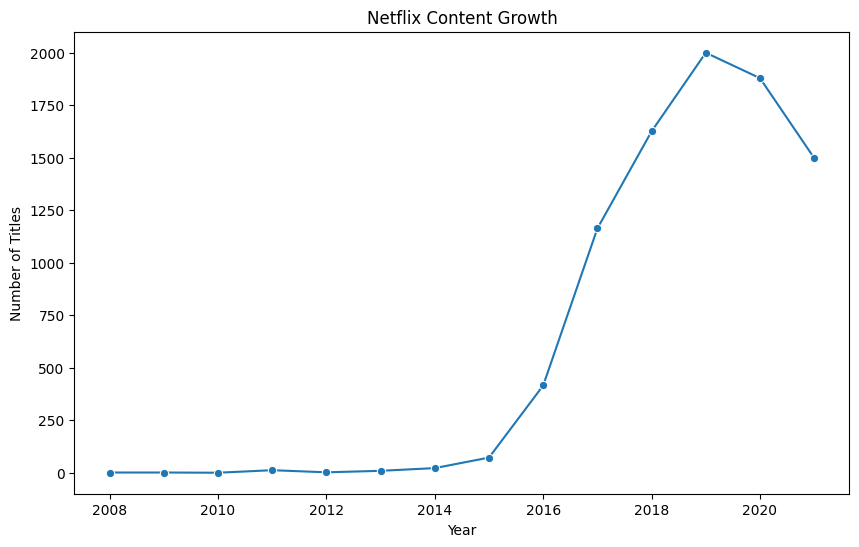

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(data=Growth_2016,marker='o')
plt.title('Netflix Content Growth')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

**IDENTITY GENERS LISTED ARE**

In [ ]:
df.explode('listed_in').groupby('listed_in')['type'].value_counts().unstack().fillna(0)

type,Movie,TV Show
listed_in,,
Action & Adventure,128.0,0.0
"Action & Adventure, Anime Features",1.0,0.0
"Action & Adventure, Anime Features, Children & Family Movies",4.0,0.0
"Action & Adventure, Anime Features, Classic Movies",2.0,0.0
"Action & Adventure, Anime Features, Horror Movies",1.0,0.0
...,...,...
"TV Horror, TV Mysteries, Teen TV Shows",0.0,1.0
"TV Horror, Teen TV Shows",0.0,2.0
"TV Sci-Fi & Fantasy, TV Thrillers",0.0,1.0


**WHICH YEAR HAD THE HIGHEST NUMBER OF RELEASES**

In [ ]:
Release=df.groupby('release_year')['title'].value_counts().sort_values(ascending=False).head(1).index[0]
Release

(np.int64(2021), 'Zero Chill')

**WHAT IS THE MEDIAN MOVIE DURATION**

In [ ]:
df_movies[df_movies['type']=='Movie']['duration_minutes'].median()

98.0

**WHICH ACTOR APPEAR IN THE HIGHEST NUMBER OF TITLES**

In [ ]:
df['cast']=df['cast'].apply(lambda x: x.split(','))

In [ ]:
df.explode('cast').groupby('cast')['title'].count().sort_values(ascending=False)

,title
cast,
Not Avaible,825
Anupam Kher,39
Rupa Bhimani,31
Takahiro Sakurai,30
Julie Tejwani,28
...,...
Joziah Lagonoy,1
Jozef Gjura,1
Joyraj Bhattacharya,1


**CREATE A NEW COLUMN:CONTENT YEAR:**

In [ ]:
current_year=pd.Timestamp.now().year

In [ ]:
df['Content Age']=current_year-df['release_year']

In [ ]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,Content Age
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,[Not Avaible],United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,6
1,s2,TV Show,Blood & Water,Not Available,"[Ama Qamata, Khosi Ngema, Gail Mabalane, Th...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,5
2,s3,TV Show,Ganglands,Julien Leclercq,"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, ...",Not Available,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,5
3,s4,TV Show,Jailbirds New Orleans,Not Available,[Not Avaible],Not Available,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,5
4,s5,TV Show,Kota Factory,Not Available,"[Mayur More, Jitendra Kumar, Ranjan Raj, Al...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"[Mark Ruffalo, Jake Gyllenhaal, Robert Downe...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019.0,19
8803,s8804,TV Show,Zombie Dumb,Not Available,[Not Avaible],Not Available,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2019.0,8
8804,s8805,Movie,Zombieland,Ruben Fleischer,"[Jesse Eisenberg, Woody Harrelson, Emma Ston...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019.0,17
8805,s8806,Movie,Zoom,Peter Hewitt,"[Tim Allen, Courteney Cox, Chevy Chase, Kat...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020.0,20


**WRITE A QUERY TO FIND TITLES WHERE COUNTRY='INDIA' AND TYPE='MOVIE'**

In [ ]:
df.loc[lambda x: (x['country']=='India')&(x['type']=='Movie')].head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,Content Age
24,s25,Movie,Jeans,S. Shankar,"[Prashanth, Aishwarya Rai Bachchan, Sri Laks...",India,2021-09-21,1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...,2021.0,28
105,s106,Movie,Angamaly Diaries,Lijo Jose Pellissery,"[Antony Varghese, Reshma Rajan, Binny Rinky ...",India,2021-09-05,2017,TV-14,128 min,"Action & Adventure, Comedies, Dramas",After growing up amidst the gang wars of his h...,2021.0,9
114,s115,Movie,Anjaam,Rahul Rawail,"[Madhuri Dixit, Shah Rukh Khan, Tinnu Anand,...",India,2021-09-02,1994,TV-14,143 min,"Dramas, International Movies, Thrillers",A wealthy industrialist’s dangerous obsession ...,2021.0,32


**GET THE COUNT OF TITLES PER RATING PER YEAR**

In [ ]:
df.groupby(['rating','release_year'])['title'].count()

rating    release_year
G         1956            1
          1958            1
          1964            1
          1968            1
          1969            1
                         ..
TV-Y7-FV  2016            2
          2018            1
UR        1974            1
          2008            1
          2016            1
Name: title, Length: 437, dtype: int64

**FIND COUNTRIES WITH LESS THAT 10 TITLES**

In [ ]:
title_count=df.groupby('country')['title'].count()
title_count

,title
country,
", France, Algeria",1
", South Korea",1
Argentina,56
"Argentina, Brazil, France, Poland, Germany, Denmark",1
"Argentina, Chile",2
...,...
Venezuela,1
"Venezuela, Colombia",1
Vietnam,7


In [ ]:
title_count[title_count<10].index

Index([', France, Algeria', ', South Korea',
       'Argentina, Brazil, France, Poland, Germany, Denmark',
       'Argentina, Chile', 'Argentina, Chile, Peru', 'Argentina, France',
       'Argentina, France, United States, Germany, Qatar', 'Argentina, Italy',
       'Argentina, Spain', 'Argentina, United States',
       ...
       'Uruguay, Argentina, Germany, Spain', 'Uruguay, Argentina, Spain',
       'Uruguay, Germany', 'Uruguay, Guatemala', 'Uruguay, Spain, Mexico',
       'Venezuela', 'Venezuela, Colombia', 'Vietnam', 'West Germany',
       'Zimbabwe'],
      dtype='object', name='country', length=690)

**FIND DIRECTOR WHO WORKED IN MORE THAN 10 COUNTRIES**

In [ ]:
worked=df.groupby('director')['country'].count().sort_values(ascending=False).drop('Not Available')
worked

,country
director,
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Marcus Raboy,16
Suhas Kadav,16
Jay Karas,14
...,...
Álvaro Delgado-Aparicio L.,1
Álvaro Brechner,1
Zuko Nodada,1


In [ ]:
worked[worked>10]

,country
director,
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Marcus Raboy,16
Suhas Kadav,16
Jay Karas,14
Cathy Garcia-Molina,13
Jay Chapman,12
Martin Scorsese,12
Youssef Chahine,12


**FIND YEARS WHERE TV SHOWS>MOVIES**

In [ ]:
MOV_TV=df.explode('type').groupby('type')['release_year'].value_counts()
MOV_TV

type     release_year
Movie    2018            767
         2017            766
         2016            658
         2019            633
         2020            517
                        ... 
TV Show  1979              1
         1981              1
         1985              1
         1989              1
         1991              1
Name: count, Length: 119, dtype: int64

In [ ]:
tv_vs_movie_by_year = MOV_TV.unstack(level='type').fillna(0)
years_more_tv_shows = tv_vs_movie_by_year[tv_vs_movie_by_year['TV Show'] > tv_vs_movie_by_year['Movie']]
print("Years where TV Shows outnumber Movies:")
print(years_more_tv_shows.index.tolist())

Years where TV Shows outnumber Movies:
[1925, 2021]


**FIND TITLE WHOSE DISCRIPTION CONTAINS THE WORD "FAMILY"**

In [ ]:
df[df['description'].str.contains('family')]['title']

,title
2,Ganglands
12,Je Suis Karl
28,Dark Skies
84,Omo Ghetto: the Saga
103,Shadow Parties
...,...
8784,Yoko and His Friends
8786,You Can Tutu
8787,You Can’t Fight Christmas
8788,You Carry Me


**GROUP TITLES BY DECADE (1990S,2000S,etc..)**

In [ ]:
df.groupby ((df['release_year']//10)*10)['title'].apply(list)

,title
release_year,
1920,[Pioneers: First Women Filmmakers*]
1940,"[Five Came Back: The Reference Films, Know You..."
1950,"[Ujala, White Christmas, Cairo Station, Dark W..."
1960,"[The Guns of Navarone, My Fair Lady, Saladin, ..."
1970,"[Jaws, Jaws 2, Return of the Prodigal Son, FTA..."
1980,"[Jaws 3, Jaws: The Revenge, Blade Runner: The ..."
1990,"[Sankofa, Avvai Shanmughi, Jeans, Minsara Kana..."
2000,"[Training Day, InuYasha the Movie 2: The Castl..."
2010,"[Resurrection: Ertugrul, Grown Ups, Dark Skies..."


**FIND THE TOP GENERE PER YEAR**

In [ ]:
top_genre_per_year = df.explode('listed_in').groupby('release_year')['listed_in'].apply(lambda x: x.value_counts().idxmax())
print(top_genre_per_year)

release_year
1925                         TV Shows
1942    Classic Movies, Documentaries
1943                    Documentaries
1944    Classic Movies, Documentaries
1945    Classic Movies, Documentaries
                    ...              
2017                    Documentaries
2018                  Stand-Up Comedy
2019                  Stand-Up Comedy
2020     Dramas, International Movies
2021                         Kids' TV
Name: listed_in, Length: 74, dtype: object


**IDENTIFY DUPLICATE TITLES**

In [ ]:
df[df['title'].duplicated()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,Content Age


**IS NETFLIX FOCUSING ON TV SHOWS OVER TIME**

In [ ]:
result=df.groupby([df['date_added'].dt.year,'type'])['type'].agg(num_added='count').unstack().fillna(0)
result

num_added        
type           Movie TV Show
date_added                  
2008.0           1.0     1.0
2009.0           2.0     0.0
2010.0           1.0     0.0
2011.0          13.0     0.0
2012.0           3.0     0.0
2013.0           6.0     4.0
2014.0          19.0     4.0
2015.0          56.0    17.0
2016.0         251.0   165.0
2017.0         838.0   325.0
2018.0        1237.0   388.0
2019.0        1424.0   575.0
2020.0        1284.0   594.0
2021.0         993.0   505.0

In [ ]:
result['TV_Ratio']=result[('num_added','TV Show')]/(result[('num_added','Movie')]+result[('num_added','TV Show')])
result

num_added          TV_Ratio
type           Movie TV Show          
date_added                            
2008.0           1.0     1.0  0.500000
2009.0           2.0     0.0  0.000000
2010.0           1.0     0.0  0.000000
2011.0          13.0     0.0  0.000000
2012.0           3.0     0.0  0.000000
2013.0           6.0     4.0  0.400000
2014.0          19.0     4.0  0.173913
2015.0          56.0    17.0  0.232877
2016.0         251.0   165.0  0.396635
2017.0         838.0   325.0  0.279450
2018.0        1237.0   388.0  0.238769
2019.0        1424.0   575.0  0.287644
2020.0        1284.0   594.0  0.316294
2021.0         993.0   505.0  0.337116

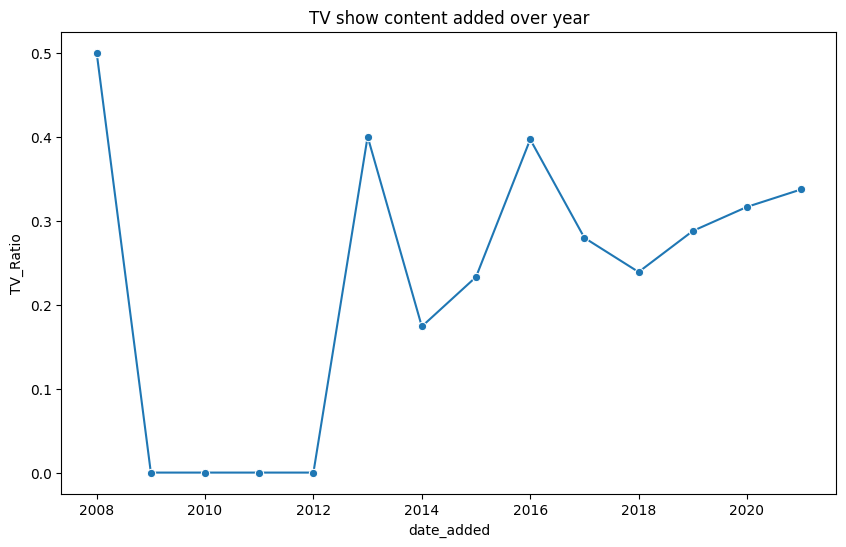

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(data=result['TV_Ratio'],marker='o')
plt.title('TV show content added over year')
plt.show()

**DO INTERNATIONAL TITLES HAVE DIFFERENT RATING DISTRIBUTIONS THAN US TITLES**

In [ ]:
def label_US(country_passed):
  if country_passed == 'Not Available':
    return 'UNKNOWN'
  elif 'United States' in country_passed:
    return 'US'
  else:
    return 'INTERNATIONAL'

In [ ]:
df['filtered_countries']=df['country'].apply(label_US)

In [ ]:
rating_table=df.groupby(['filtered_countries','rating'])['title'].count().unstack().fillna(0)
rating_table

rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
filtered_countries,,,,,,,,,,,,,,
INTERNATIONAL,2.0,2.0,37.0,38.0,49.0,128.0,1433.0,101.0,1833.0,469.0,100.0,89.0,3.0,2.0
UNKNOWN,0.0,0.0,0.0,6.0,8.0,11.0,230.0,30.0,277.0,90.0,80.0,98.0,1.0,0.0
US,39.0,1.0,43.0,243.0,433.0,660.0,497.0,89.0,1101.0,304.0,127.0,147.0,2.0,1.0


**ARE NEWER MOVIES GETTING SHOTTER OR LONGER**

In [ ]:
movie_duration=df_movies.groupby('release_year')['duration_minutes'].mean()
movie_duration

,duration_minutes
release_year,
1942,35.000000
1943,62.666667
1944,52.000000
1945,51.333333
1946,58.000000
...,...
2017,95.535248
2018,96.185137
2019,93.466035


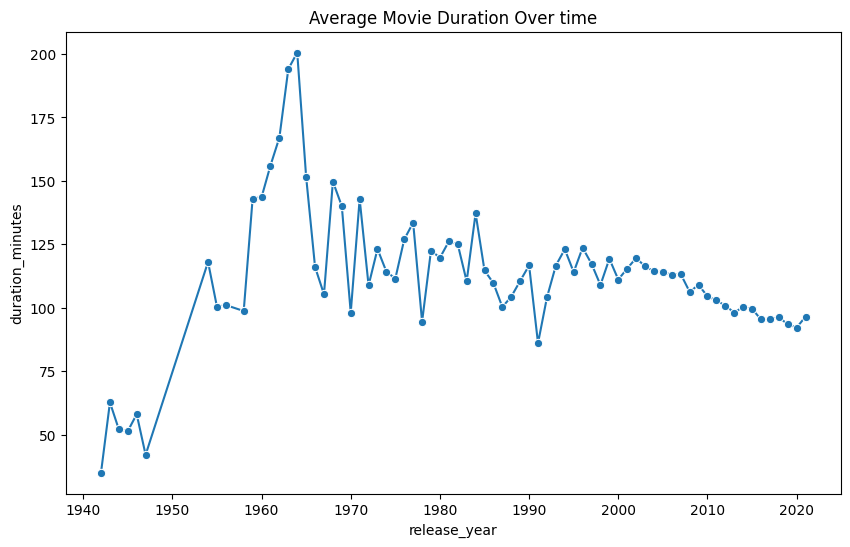

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(data=movie_duration,marker='o')
plt.title('Average Movie Duration Over time')
plt.show()

**COMPARE GENRE POPULARITY PRE-2015 VS POST-2015**

In [ ]:
df['prepost_2015']=df['release_year'].apply(lambda x: 'pre 2015' if x<2015 else 'post 2015')

In [ ]:
compare_2015=df.explode('listed_in').groupby('prepost_2015')['listed_in'].value_counts().unstack().fillna(0)
compare_2015

listed_in,Action & Adventure,"Action & Adventure, Anime Features","Action & Adventure, Anime Features, Children & Family Movies","Action & Adventure, Anime Features, Classic Movies","Action & Adventure, Anime Features, Horror Movies","Action & Adventure, Anime Features, International Movies","Action & Adventure, Anime Features, Sci-Fi & Fantasy","Action & Adventure, Children & Family Movies","Action & Adventure, Children & Family Movies, Classic Movies","Action & Adventure, Children & Family Movies, Comedies",...,"TV Dramas, TV Sci-Fi & Fantasy, Teen TV Shows","TV Dramas, TV Thrillers","TV Dramas, Teen TV Shows","TV Horror, TV Mysteries, TV Sci-Fi & Fantasy","TV Horror, TV Mysteries, TV Thrillers","TV Horror, TV Mysteries, Teen TV Shows","TV Horror, Teen TV Shows","TV Sci-Fi & Fantasy, TV Thrillers",TV Shows,Thrillers
prepost_2015,,,,,,,,,,,,,,,,,,,,,
post 2015,68.0,1.0,4.0,0.0,1.0,11.0,0.0,1.0,0.0,2.0,...,1.0,5.0,4.0,4.0,4.0,1.0,2.0,1.0,9.0,45.0
pre 2015,60.0,0.0,0.0,2.0,0.0,27.0,4.0,1.0,4.0,3.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,7.0,20.0


In [ ]:
row_count=compare_2015.sum(axis=1)
row_count

,0
prepost_2015,
post 2015,6214.0
pre 2015,2590.0


In [ ]:
compare_2015=compare_2015.div(row_count,axis=0)*100
compare_2015

listed_in,Action & Adventure,"Action & Adventure, Anime Features","Action & Adventure, Anime Features, Children & Family Movies","Action & Adventure, Anime Features, Classic Movies","Action & Adventure, Anime Features, Horror Movies","Action & Adventure, Anime Features, International Movies","Action & Adventure, Anime Features, Sci-Fi & Fantasy","Action & Adventure, Children & Family Movies","Action & Adventure, Children & Family Movies, Classic Movies","Action & Adventure, Children & Family Movies, Comedies",...,"TV Dramas, TV Sci-Fi & Fantasy, Teen TV Shows","TV Dramas, TV Thrillers","TV Dramas, Teen TV Shows","TV Horror, TV Mysteries, TV Sci-Fi & Fantasy","TV Horror, TV Mysteries, TV Thrillers","TV Horror, TV Mysteries, Teen TV Shows","TV Horror, Teen TV Shows","TV Sci-Fi & Fantasy, TV Thrillers",TV Shows,Thrillers
prepost_2015,,,,,,,,,,,,,,,,,,,,,
post 2015,1.094303,0.016093,0.064371,0.00000,0.016093,0.177020,0.00000,0.016093,0.00000,0.032185,...,0.016093,0.080463,0.064371,0.064371,0.064371,0.016093,0.032185,0.016093,0.144834,0.724171
pre 2015,2.316602,0.000000,0.000000,0.07722,0.000000,1.042471,0.15444,0.038610,0.15444,0.115830,...,0.000000,0.000000,0.077220,0.000000,0.000000,0.000000,0.000000,0.000000,0.270270,0.772201


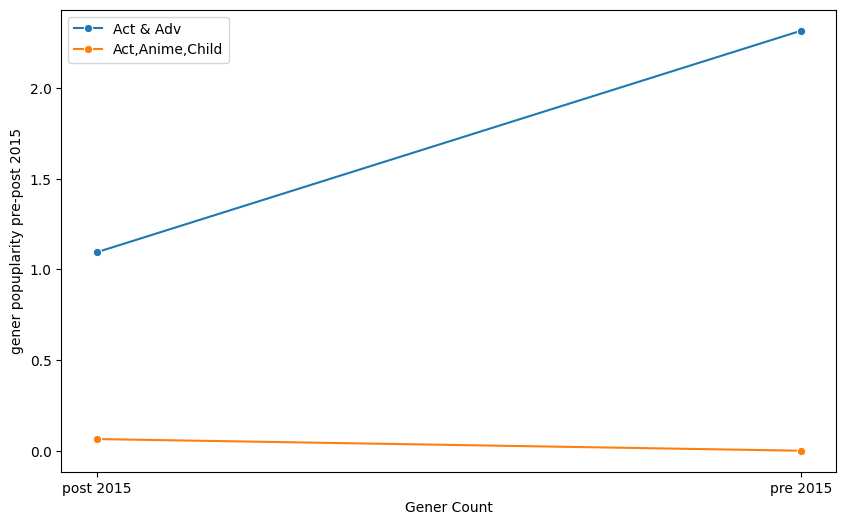

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(data=compare_2015['Action & Adventure'],marker='o',label='Act & Adv')
plt.xlabel('Gener Count')
plt.ylabel('gener popuplarity pre-post 2015')
sns.lineplot(data=compare_2015['Action & Adventure, Anime Features, Children & Family Movies'],marker='o',label='Act,Anime,Child')
plt.show()

**WHICH GENERS ARE COUNTRY SPECIFIC**

In [ ]:
genre_country=df.explode('country').explode('listed_in').groupby('listed_in')['country'].value_counts()
genre_country

listed_in           country                                     
Action & Adventure  United States                                   64
                    United Kingdom, United States                    8
                    United Kingdom                                   7
                    Canada                                           5
                    United States, Canada                            3
                                                                    ..
Thrillers           United States, Hong Kong                         1
                    United States, India, France                     1
                    United States, Italy                             1
                    United States, Malta, France, United Kingdom     1
                    United States, Spain                             1
Name: count, Length: 2795, dtype: int64

In [ ]:
genre_country.unstack().fillna(0).idxmax(axis=1)

,0
listed_in,
Action & Adventure,United States
"Action & Adventure, Anime Features",Not Available
"Action & Adventure, Anime Features, Children & Family Movies",Japan
"Action & Adventure, Anime Features, Classic Movies",Japan
"Action & Adventure, Anime Features, Horror Movies",Japan
...,...
"TV Horror, TV Mysteries, Teen TV Shows",United States
"TV Horror, Teen TV Shows",United States
"TV Sci-Fi & Fantasy, TV Thrillers",Canada


**IDENTIFY CONTENT GAPS(GENERS UNDERREPRESENTED IN BIG MARKETS)**

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,Content Age,filtered_countries,prepost_2015
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,[Not Avaible],United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,6,US,post 2015
1,s2,TV Show,Blood & Water,Not Available,"[Ama Qamata, Khosi Ngema, Gail Mabalane, Th...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,5,INTERNATIONAL,post 2015
2,s3,TV Show,Ganglands,Julien Leclercq,"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, ...",Not Available,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,5,UNKNOWN,post 2015
3,s4,TV Show,Jailbirds New Orleans,Not Available,[Not Avaible],Not Available,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,5,UNKNOWN,post 2015
4,s5,TV Show,Kota Factory,Not Available,"[Mayur More, Jitendra Kumar, Ranjan Raj, Al...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,5,INTERNATIONAL,post 2015


In [ ]:
df['country']=df['country'].str.split(',')
df['listed_in']=df['listed_in'].str.split(',')

In [ ]:
df=df.explode('country').explode('listed_in')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,Content Age,filtered_countries,prepost_2015
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,[Not Avaible],United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,6,US,post 2015
1,s2,TV Show,Blood & Water,Not Available,"[Ama Qamata, Khosi Ngema, Gail Mabalane, Th...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2021.0,5,INTERNATIONAL,post 2015
1,s2,TV Show,Blood & Water,Not Available,"[Ama Qamata, Khosi Ngema, Gail Mabalane, Th...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",2021.0,5,INTERNATIONAL,post 2015
1,s2,TV Show,Blood & Water,Not Available,"[Ama Qamata, Khosi Ngema, Gail Mabalane, Th...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",2021.0,5,INTERNATIONAL,post 2015
2,s3,TV Show,Ganglands,Julien Leclercq,"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, ...",Not Available,2021-09-24,2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...,2021.0,5,UNKNOWN,post 2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8805,s8806,Movie,Zoom,Peter Hewitt,"[Tim Allen, Courteney Cox, Chevy Chase, Kat...",United States,2020-01-11,2006,PG,88 min,Children & Family Movies,"Dragged from civilian life, a former superhero...",2020.0,20,US,pre 2015
8805,s8806,Movie,Zoom,Peter Hewitt,"[Tim Allen, Courteney Cox, Chevy Chase, Kat...",United States,2020-01-11,2006,PG,88 min,Comedies,"Dragged from civilian life, a former superhero...",2020.0,20,US,pre 2015
8806,s8807,Movie,Zubaan,Mozez Singh,"[Vicky Kaushal, Sarah-Jane Dias, Raaghav Cha...",India,2019-03-02,2015,TV-14,111 min,Dramas,A scrappy but poor boy worms his way into a ty...,2019.0,11,INTERNATIONAL,post 2015
8806,s8807,Movie,Zubaan,Mozez Singh,"[Vicky Kaushal, Sarah-Jane Dias, Raaghav Cha...",India,2019-03-02,2015,TV-14,111 min,International Movies,A scrappy but poor boy worms his way into a ty...,2019.0,11,INTERNATIONAL,post 2015


In [ ]:
gener_count=df.groupby(['country','listed_in']).size().reset_index(name='count')
gener_count

,country,listed_in,count
0,,Dramas,1
1,,Independent Movies,1
2,,International Movies,5
3,,TV Dramas,1
4,,Classic Movies,1
...,...,...,...
2496,West Germany,International Movies,1
2497,West Germany,Documentaries,1
2498,Zimbabwe,International Movies,1
2499,Zimbabwe,Romantic Movies,1


In [ ]:
content_gap=gener_count[gener_count['count']<10]
content_gap

,country,listed_in,count
0,,Dramas,1
1,,Independent Movies,1
2,,International Movies,5
3,,TV Dramas,1
4,,Classic Movies,1
...,...,...,...
2496,West Germany,International Movies,1
2497,West Germany,Documentaries,1
2498,Zimbabwe,International Movies,1
2499,Zimbabwe,Romantic Movies,1


**IS THERE RELATIONSHIP BETWEEN RATING AND DURATION**

In [ ]:
movies=df[df['type']=='Movie'].copy()

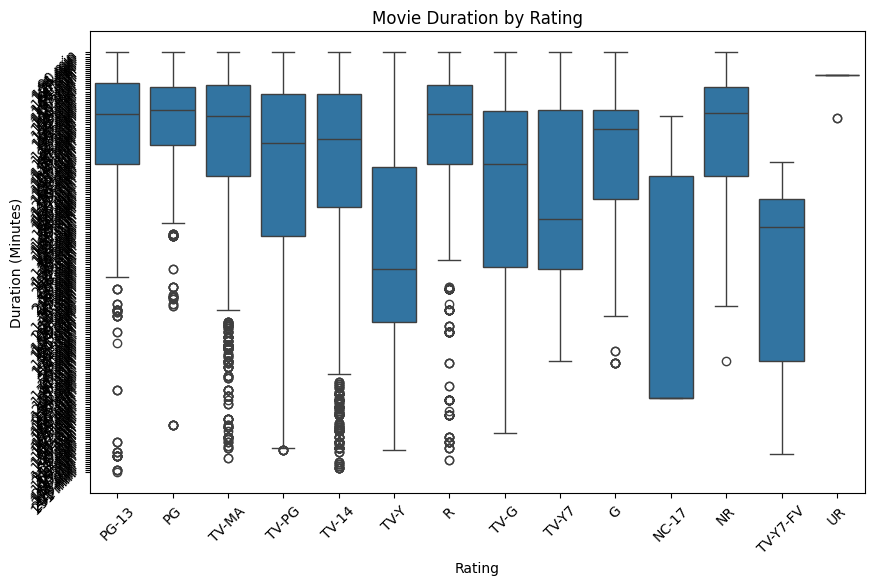

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='rating', y='duration', data=movies)
plt.title('Movie Duration by Rating')
plt.xlabel('Rating')
plt.ylabel('Duration (Minutes)')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

In [ ]:
tv_show=df[df['type']=='TV Show'].copy()

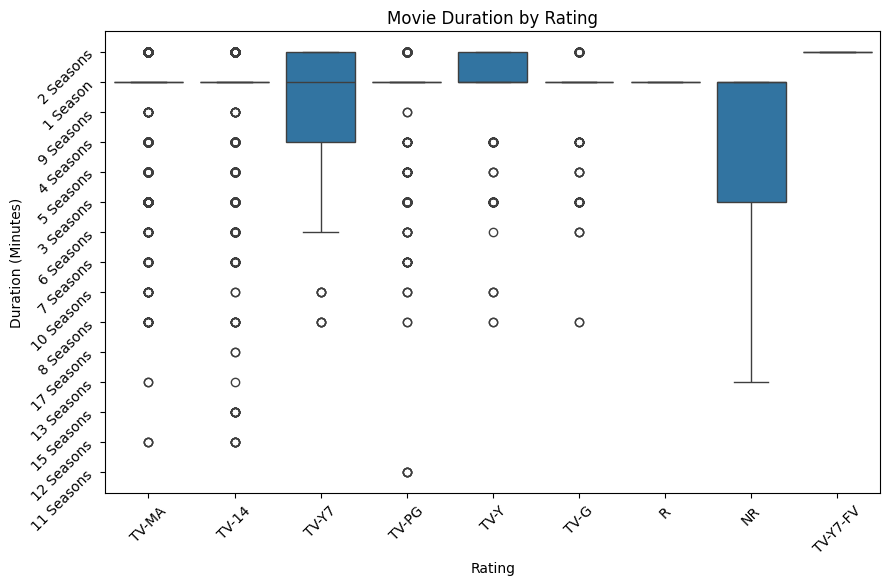

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='rating', y='duration', data=tv_show)
plt.title('Movie Duration by Rating')
plt.xlabel('Rating')
plt.ylabel('Duration (Minutes)')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

**WHICH COUNTRY ENTERED NETFLIX MOST RECENTLY**

In [ ]:
countries_added=df.explode('country')

In [ ]:
countries_added.groupby('country')['date_added'].agg(dated='min').sort_values(by='dated',ascending=False)

,dated
country,
Ethiopia,2021-09-24
Burkina Faso,2021-09-24
Ghana,2021-09-24
Syria,2021-05-27
Cameroon,2021-04-04
...,...
Mexico,2011-05-17
Spain,2011-05-17
France,2011-05-17
